![Getaround](https://lever-client-logos.s3.amazonaws.com/2bd4cdf9-37f2-497f-9096-c2793296a75f-1568844229943.png)

# What should a car rent for?

The brief asks for a pricing model served at `/predict`: given a car, suggest a daily rental
price. This notebook is where that model was studied — what to clean, which family of models is
worth serving, and what the winner actually knows. The delay analysis, the other half of the
brief, lives in the dashboard, where the product manager can move the threshold and the scope.

The answer has the same shape whichever way it is read: **the price is the car, not the
equipment.**

---

### How this notebook is organised

| Section | What it does |
|---|---|
| 1 | The pricing model: cleaning, four models compared, what the winner knows |
| 2 | What ships |

Every claim below is the output of the cell above it.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

# Plotly figures are rendered as static images rather than interactive widgets.
# Reason: this notebook has to stay readable wherever it is opened.
# GitHub, nbviewer and PDF exports all strip interactive plotly output and would show nothing.
pio.renderers.default = 'png'

# Charts are also written to disk, so the README can reuse them.
IMAGES = Path('images')
IMAGES.mkdir(exist_ok=True)

# One seed for the whole notebook: the train/test split, every model fit and the grid search
# read it, so every number below is reproducible from this line.
RANDOM_STATE = 42

# The palette: one blue for a single measure, blue/red when a chart carries a contrast.
BLUE, RED = '#2a78d6', '#e34948'


def show(fig, name, height=520):
    """Render a figure in the notebook and save it as a PNG under images/."""
    fig.update_layout(width=980, height=height, template='plotly_white',
                      margin=dict(t=80, b=60, l=70, r=40))
    fig.write_image(IMAGES / f'{name}.png', scale=2)
    fig.show()


pricing = pd.read_csv('data/get_around_pricing_project.csv').drop(columns=['Unnamed: 0'])
print(f'pricing file: {pricing.shape[0]:,} cars x {pricing.shape[1]} columns'.replace(',', ' '))
pricing.head()

pricing file: 4 843 cars x 14 columns


,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
0,Citroën,140411,100,diesel,black,convertible,True,True,False,False,True,True,True,106
1,Citroën,13929,317,petrol,grey,convertible,True,True,False,False,False,True,True,264
2,Citroën,183297,120,diesel,white,convertible,False,False,False,False,True,False,True,101
3,Citroën,128035,135,diesel,red,convertible,True,True,False,False,True,True,True,158
4,Citroën,97097,160,diesel,silver,convertible,True,True,False,False,False,True,True,183


## 1. The pricing model behind `/predict`

The brief asks for a pricing recommendation the API serves: given a car, suggest a
daily price. 4 843 cars, thirteen features, one target.

### 1.1 Three impossible values, and what removing them costs

In [2]:
impossible = ((pricing['mileage'] < 0) | (pricing['mileage'] > 500_000)
              | (pricing['engine_power'] == 0))
print(f'mileage below zero        : {(pricing["mileage"] < 0).sum()} '
      f'-> {list(pricing.loc[pricing["mileage"] < 0, "mileage"])}')
print(f'mileage above 500 000 km  : {(pricing["mileage"] > 500_000).sum()} '
      f'-> {list(pricing.loc[pricing["mileage"] > 500_000, "mileage"])}')
print(f'engine power of zero      : {(pricing["engine_power"] == 0).sum()}')
print(f'\nrows flagged: {impossible.sum()} of {len(pricing):,} = {impossible.mean():.2%}'.replace(',', ' '))
print(f'\nprice below 25 EUR/day    : {(pricing["rental_price_per_day"] < 25).sum()} cars '
      f'-> {sorted(pricing.loc[pricing["rental_price_per_day"] < 25, "rental_price_per_day"].unique())}')

mileage below zero        : 1 -> [-64]
mileage above 500 000 km  : 1 -> [1000376]
engine power of zero      : 1

rows flagged: 3 of 4 843 = 0.06%

price below 25 EUR/day    : 18 cars -> [np.int64(10), np.int64(14), np.int64(20), np.int64(22), np.int64(24)]


Three rows are physically impossible — a car cannot have run −64 km, nor 1 000 376, nor have a
zero-power engine — and they go. That is **0.06% of the file**, too small to change a score;
they are removed because serving a prediction fitted on a negative mileage is indefensible, not
because it helps.

The eighteen cars priced under €25 a day stay. Ten euros is a strange price but it is not an
impossible one, and this is a model of what owners *do* charge.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import (GridSearchCV, KFold, cross_val_score, cross_validate,
                                     train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

clean = pricing[~impossible].reset_index(drop=True)
NUMERIC = ['mileage', 'engine_power']
CATEGORICAL = ['model_key', 'fuel', 'paint_color', 'car_type']
BOOLEAN = ['private_parking_available', 'has_gps', 'has_air_conditioning', 'automatic_car',
           'has_getaround_connect', 'has_speed_regulator', 'winter_tires']
FEATURES = NUMERIC + CATEGORICAL + BOOLEAN
TARGET = 'rental_price_per_day'

X, y = clean[FEATURES], clean[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# handle_unknown matters here for a reason that is not statistical: the endpoint is public and
# will be sent model_key values that were never in the training set. Unknown levels have to be
# encoded, not raise.
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUMERIC),
    ('cat', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=10,
                          sparse_output=False), CATEGORICAL),
    ('bool', 'passthrough', BOOLEAN),
])
cv = KFold(5, shuffle=True, random_state=RANDOM_STATE)
print(f'train {len(X_train):,} cars | test {len(X_test):,} cars'.replace(',', ' '),
      f'| price {y.min()}-{y.max()} EUR, median {y.median():.0f} EUR')

train 3 872 cars | test 968 cars | price 10-422 EUR, median 119 EUR


### 1.2 Four models, and what each is worth

In [4]:
CANDIDATES = {
    'the median price of every car': DummyRegressor(strategy='median'),
    'linear regression': LinearRegression(),
    'random forest': RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'gradient boosting': HistGradientBoostingRegressor(random_state=RANDOM_STATE),
}
rows = []
for name, estimator in CANDIDATES.items():
    pipe = Pipeline([('pre', preprocessor), ('model', estimator)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv,
                            scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'})
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    # MAE is the criterion, in euros; R2 is kept beside it as a second reading.
    row = {'model': name, 'CV MAE': -scores['test_mae'].mean(),
           'CV MAE std': scores['test_mae'].std(), 'CV R2': scores['test_r2'].mean(),
           'test MAE': mean_absolute_error(y_test, pred), 'test R2': r2_score(y_test, pred)}
    rows.append(row)

leaderboard = pd.DataFrame(rows)
print(leaderboard.to_string(index=False, float_format='{:.3f}'.format))

by_model = leaderboard.set_index('model')
print(f"\ngradient boosting minus random forest, CV MAE: "
      f"{by_model.loc['gradient boosting', 'CV MAE'] - by_model.loc['random forest', 'CV MAE']:+.2f} EUR")

                        model  CV MAE  CV MAE std  CV R2  test MAE  test R2
the median price of every car  23.441       0.682 -0.009    24.131   -0.002
            linear regression  12.336       0.153  0.697    12.409    0.713
                random forest  10.593       0.156  0.748    10.877    0.747
            gradient boosting  10.696       0.207  0.755    10.933    0.756

gradient boosting minus random forest, CV MAE: +0.10 EUR


Charging every car the median €119 is wrong by **€24.13 on average**. The linear model nearly
halves that to €12.41, and the two ensembles take about another €1.50 off it.

The criterion is the **cross-validated MAE**, the one `training/train.py` uses: it reads in euros,
and it is measured on the training split only. On it the two ensembles are **tied**: the default
gradient boosting is €0.10 *behind* the random forest, when a model's MAE moves by €0.16 to €0.21
from one fold to the next.

Only the gradient boosting is tuned below; the random forest stays at its defaults. The comparison
that follows is therefore a tuned model against an untuned one, and should be read that way.

In [5]:
search = GridSearchCV(
    Pipeline([('pre', preprocessor), ('model', HistGradientBoostingRegressor(random_state=RANDOM_STATE))]),
    {'model__learning_rate': [0.05, 0.1], 'model__max_iter': [200, 400],
     'model__max_leaf_nodes': [15, 31, 63], 'model__min_samples_leaf': [10, 20, 40]},
    cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
search.fit(X_train, y_train)
best = search.best_estimator_
pred = best.predict(X_test)

print('best parameters:', {k.replace('model__', ''): v for k, v in search.best_params_.items()})
default_cv_mae = leaderboard.set_index('model').loc['gradient boosting', 'CV MAE']
print(f'CV MAE       : {-search.best_score_:.2f} EUR '
      f'({default_cv_mae + search.best_score_:.2f} EUR better than the default gradient boosting)')
print(f'             : {by_model.loc["random forest", "CV MAE"] + search.best_score_:.2f} EUR '
      f'better than the random forest, left at its defaults')
print(f'test R2      : {r2_score(y_test, pred):.4f}')
print(f'test MAE     : {mean_absolute_error(y_test, pred):.2f} EUR')
print(f'median error : {np.median(np.abs(y_test - pred)):.2f} EUR on a median price of {y_test.median():.0f} EUR')

best parameters: {'learning_rate': 0.05, 'max_iter': 400, 'max_leaf_nodes': 31, 'min_samples_leaf': 10}
CV MAE       : 10.34 EUR (0.36 EUR better than the default gradient boosting)
             : 0.26 EUR better than the random forest, left at its defaults
test R2      : 0.7705
test MAE     : 10.59 EUR
median error : 7.12 EUR on a median price of 120 EUR


**€10.59 of average error on a median price of €120**, and half the cars are priced within
**€7.12**. Tuning bought €0.36 of cross-validated MAE over the default gradient boosting, which
puts the tuned model €0.26 ahead of the random forest — more than the fold-to-fold spread in
the table above. The grid of 36 combinations is in the cell.

### 1.3 The price is the car, not the equipment

In [6]:
GROUPS = {
    'everything (13 features)': (NUMERIC, CATEGORICAL, BOOLEAN),
    'the car only — engine, mileage, model, fuel, type': (NUMERIC, ['model_key', 'fuel', 'car_type'], []),
    'the options only — 7 booleans and the colour': ([], ['paint_color'], BOOLEAN),
    'engine_power alone': (['engine_power'], [], []),
}
for label, (num, cat, boo) in GROUPS.items():
    steps = ([('num', StandardScaler(), num)] if num else [])
    steps += ([('cat', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=10,
                                     sparse_output=False), cat)] if cat else [])
    steps += ([('bool', 'passthrough', boo)] if boo else [])
    pipe = Pipeline([('pre', ColumnTransformer(steps)),
                     ('model', HistGradientBoostingRegressor(random_state=RANDOM_STATE))])
    s = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='r2')
    print(f'{label:<52} CV R2 {s.mean():.3f} +/-{s.std():.3f}')

everything (13 features)                             CV R2 0.755 +/-0.040


the car only — engine, mileage, model, fuel, type    CV R2 0.717 +/-0.040


the options only — 7 booleans and the colour         CV R2 0.344 +/-0.025


engine_power alone                                   CV R2 0.460 +/-0.028


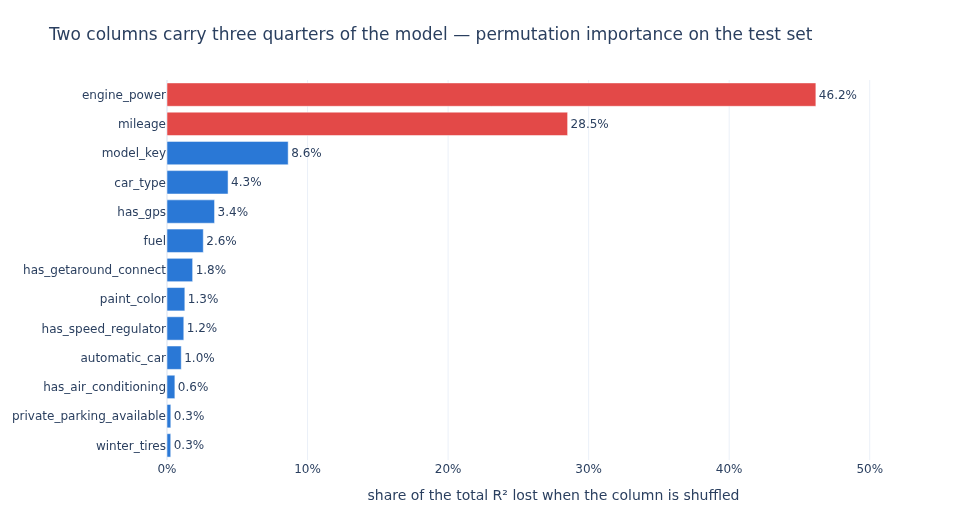

engine_power                 46.2
mileage                      28.5
model_key                     8.6
car_type                      4.3
has_gps                       3.4
fuel                          2.6
has_getaround_connect         1.8
paint_color                   1.3
has_speed_regulator           1.2
automatic_car                 1.0
has_air_conditioning          0.6
private_parking_available     0.3
winter_tires                  0.3


In [7]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(best, X_test, y_test, n_repeats=10,
                              random_state=RANDOM_STATE, scoring='r2')
importance = (pd.Series(perm.importances_mean, index=FEATURES)
              .sort_values() / perm.importances_mean.sum())
fig = go.Figure(go.Bar(
    x=importance.values, y=importance.index, orientation='h',
    marker_color=[RED if f in NUMERIC else BLUE for f in importance.index],
    text=[f'{v:.1%}' for v in importance.values], textposition='outside',
))
fig.update_layout(
    title='Two columns carry three quarters of the model — permutation importance on the test set',
    xaxis=dict(title='share of the total R² lost when the column is shuffled', tickformat='.0%',
               range=[0, 0.55]),
    yaxis=dict(title=None), showlegend=False,
)
show(fig, '4_feature_importance', height=520)
print(importance.sort_values(ascending=False).mul(100).round(1)
      .rename('% of the total drop').to_string())

**The two columns an owner cannot change carry 75% of the model.** `engine_power` alone is 46.2% of
it and `mileage` 28.5%; the seven equipment booleans and the paint colour together are 9.9%.

Fitted on the car's own characteristics only, the model reaches **CV R² 0.717**. Adding everything
the owner controls — GPS, air conditioning, automatic gearbox, Connect, speed regulator, winter
tyres, private parking, colour — takes it to **0.755**, under four points. Those same options
fitted *alone* reach 0.344.

This is the honest description of what `/predict` does: it tells an owner **what their car is
worth**, not what to do about it. That is still the useful answer for the recommendation the brief
asks for — an owner setting a price wants the market rate for their car — but it should not be
sold as an optimiser, because there is very little in it to optimise.

In [8]:
final = Pipeline([('pre', preprocessor),
                  ('model', HistGradientBoostingRegressor(random_state=RANDOM_STATE,
                                                          **{k.replace('model__', ''): v
                                                             for k, v in search.best_params_.items()}))])
final.fit(X, y)   # the deployed model is refitted on all 4 840 cars, train and test

sample = X.head(2).values.tolist()
print('the pipeline training/train.py fits, refitted on all',
      f'{len(X):,} cars'.replace(',', ' '))
print(f'  steps        : {[name for name, _ in final.steps]}')
print(f'  feature order: {FEATURES}')
print(f'\nthe endpoint contract, checked here so the API cannot disagree with the notebook:')
print(f'  input      : {json.dumps({"input": sample})[:108]}...')
print(f'  prediction : {[round(float(v), 2) for v in final.predict(X.head(2))]} EUR/day')

the pipeline training/train.py fits, refitted on all 4 840 cars
  steps        : ['pre', 'model']
  feature order: ['mileage', 'engine_power', 'model_key', 'fuel', 'paint_color', 'car_type', 'private_parking_available', 'has_gps', 'has_air_conditioning', 'automatic_car', 'has_getaround_connect', 'has_speed_regulator', 'winter_tires']

the endpoint contract, checked here so the API cannot disagree with the notebook:
  input      : {"input": [[140411, 100, "Citro\u00ebn", "diesel", "black", "convertible", true, true, false, false, true, t...
  prediction : [107.91, 264.38] EUR/day


This notebook stops here, one step short of an artefact. **The model that ships is fitted and
registered by [`training/train.py`](training/train.py)**, which replays this comparison in MLflow
— one run per candidate, the gradient boosting grid included — and registers the winner as
`challenger`. [`training/promote.py`](training/promote.py) moves `champion` to it only after a
review, and only if its held-out MAE is lower. The API resolves
`models:/getaround-pricing-model@champion` at startup, so promoting a better model is an alias
move rather than a redeployment.

Two properties of that split are worth stating. What gets logged is **the whole pipeline** —
scaler, encoder and regressor — so the API owns no feature engineering and only ever calls
`.predict(...)`; the column order and the column types it enforces come from the logged signature
rather than from a list written twice. And the registered model is **refitted on all 4 840 cars**,
train and test together: the split existed to choose the model, and once chosen there is no reason
to serve a version trained on 80% of the data.

The two prices printed above are the check that keeps the notebook and the endpoint honest: the
deployed `/predict` returns the same two numbers for the same two cars.

## 2. What ships

**1. A gradient boosting, chosen in MLflow.** `training/train.py` evaluates every candidate of
section 1.2 as its own run, picks the winner on cross-validated MAE and registers it as
`challenger`; `training/promote.py` makes it the `champion` after a review. The comparison above
is the study; the MLflow runs are the record.

**2. `/predict` returns the market rate for a car, and should be presented that way.** Two columns
the owner cannot change carry three quarters of the model. An owner who wants a higher price needs
a different car, not a different checkbox — the model is honest about that, and the product copy
should be too.

**3. Two ways to ask it.** The API in `api/` loads `@champion` at startup and serves `/predict`,
documented at `/docs`. The dashboard's Pricing page is a form that calls that same endpoint, so an
owner gets a price without writing a line of code. Both run as Hugging Face Spaces, and the README
carries the URLs.